### ML analysis from data collected from model_processing_v3 notebook

In [23]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn

In [24]:
# --- Load parquets + metadata, align rows in paired order --------------------
DATA = Path("model_data/adni")
SHORT_T1 = DATA / "t1_adc_short_data"
SHORT_DTI = DATA / "dti_adc_short_data"
meta_long = pd.read_csv(DATA / "paired_df_long.csv")
meta_short = pd.read_csv(DATA / "paired_df_short.csv")
# Rest of notebook defaults to long cohort (paired_df_long + long parquets).
meta = meta_long

In [25]:
key_col = {
    "t1_gm": "t1_image_subject_id",
    "t1_wm": "t1_image_subject_id",
    "t1_csf": "t1_image_subject_id",
    "dti_gm": "dti_image_subject_id",
    "dti_wm": "dti_image_subject_id",
    "dti_csf": "dti_image_subject_id",
}
parquet_paths_long = {
    "t1_gm": DATA / "t1_long_data" / "t1_long_masked_gm.parquet",
    "t1_wm": DATA / "t1_long_data" / "t1_long_masked_wm.parquet",
    "t1_csf": DATA / "t1_long_data" / "t1_long_masked_csf.parquet",
    "dti_gm": DATA / "dti_long_data" / "dti_long_masked_gm_md.parquet",
    "dti_wm": DATA / "dti_long_data" / "dti_long_masked_wm_md.parquet",
    "dti_csf": DATA / "dti_long_data" / "dti_long_masked_csf_md.parquet",
}
parquet_paths_short = {
    "t1_gm": SHORT_T1 / "t1_short_masked_gm.parquet",
    "t1_wm": SHORT_T1 / "t1_short_masked_wm.parquet",
    "t1_csf": SHORT_T1 / "t1_short_masked_csf.parquet",
    "dti_gm": SHORT_DTI / "dti_short_masked_gm_adc.parquet",
    "dti_wm": SHORT_DTI / "dti_short_masked_wm_adc.parquet",
    "dti_csf": SHORT_DTI / "dti_short_masked_csf_adc.parquet",
}

X_raw_long = {
    k: pd.read_parquet(p).loc[meta_long[key_col[k]]].values.astype(np.float32)
    for k, p in parquet_paths_long.items()
}
X_raw_short = {
    k: pd.read_parquet(p).loc[meta_short[key_col[k]]].values.astype(np.float32)
    for k, p in parquet_paths_short.items()
}

# Backward-compatible names (long cohort) for cells below
parquet_paths = parquet_paths_long
X_raw = X_raw_long

In [26]:
for k, X in X_raw_long.items():
    print(f" long {k:>7s}: {X.shape}")
print(
    f"meta_long: {meta_long.shape}  | groups: {meta_long['group'].value_counts(dropna=False).to_dict()}"
)
for k, X in X_raw_short.items():
    print(f"short {k:>7s}: {X.shape}")
print(
    f"meta_short: {meta_short.shape}  | groups: {meta_short['group'].value_counts(dropna=False).to_dict()}"
)

 long   t1_gm: (787, 451681)
 long   t1_wm: (787, 283320)
 long  t1_csf: (787, 173822)
 long  dti_gm: (787, 451681)
 long  dti_wm: (787, 283320)
 long dti_csf: (787, 173822)
meta_long: (787, 8)  | groups: {'CN': 400, 'MCI': 246, 'Dementia': 141}
short   t1_gm: (292, 451681)
short   t1_wm: (292, 283320)
short  t1_csf: (292, 173822)
short  dti_gm: (292, 451681)
short  dti_wm: (292, 283320)
short dti_csf: (292, 173822)
meta_short: (292, 8)  | groups: {'CN': 149, 'MCI': 89, 'Dementia': 54}


In [16]:
# --- StandardScaler + PCA(100) per modality; combined: 6 modalities (pre-PCA),
#     min-max to [0,1] using CN-only fit, applied to all rows, then PCA(100) ----
N_PC = 100
scalers, pcas, X_pca = {}, {}, {}
for k, X in X_raw.items():
    sc = StandardScaler().fit(X)
    Xs = sc.transform(X)
    pca = PCA(n_components=N_PC, random_state=0).fit(Xs)
    scalers[k], pcas[k], X_pca[k] = sc, pca, pca.transform(Xs).astype(np.float32)
    print(f"{k:>7s}: {X.shape} -> {X_pca[k].shape}  | var explained = {pca.explained_variance_ratio_.sum():.3f}")

  t1_gm: (787, 451681) -> (787, 100)  | var explained = 0.631
  t1_wm: (787, 283320) -> (787, 100)  | var explained = 0.745
 t1_csf: (787, 173822) -> (787, 100)  | var explained = 0.590
 dti_gm: (787, 451681) -> (787, 100)  | var explained = 0.850
 dti_wm: (787, 283320) -> (787, 100)  | var explained = 0.889
dti_csf: (787, 173822) -> (787, 100)  | var explained = 0.860


In [17]:
MODALITY_ORDER = ("t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf")
X_concat = np.hstack([X_raw[k] for k in MODALITY_ORDER]).astype(np.float32)
cn_mask = meta["group"].eq("CN").values
mm_cn = MinMaxScaler(feature_range=(0, 1)).fit(X_concat[cn_mask])
X_concat_01 = mm_cn.transform(X_concat).astype(np.float32)
pca_combined = PCA(n_components=N_PC, random_state=0).fit(X_concat_01)
X_combined = pca_combined.transform(X_concat_01).astype(np.float32)
print(
    f"combined: {X_concat.shape} -> [minmax fit CN n={cn_mask.sum()}] -> "
    f"{X_concat_01.shape} -> PCA({N_PC}) -> {X_combined.shape}  "
    f"| var explained = {pca_combined.explained_variance_ratio_.sum():.3f}"
)

combined: (787, 1817646) -> [minmax fit CN n=400] -> (787, 1817646) -> PCA(100) -> (787, 100)  | var explained = 0.709


In [18]:
# --- SVM eval helper: balanced class weights, report bAcc / Sens / Spec ------
def eval_svm(X, y, name="", test_size=0.2, seed=0):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, stratify=y, random_state=seed)
    clf = SVC(class_weight="balanced", random_state=seed).fit(Xtr, ytr)
    yp = clf.predict(Xte)
    tn, fp, fn, tp = confusion_matrix(yte, yp, labels=[0, 1]).ravel()
    bacc = balanced_accuracy_score(yte, yp)
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    print(f"  {name:>10s}  bAcc={bacc:.3f}  Sens={sens:.3f}  Spec={spec:.3f}  "
          f"(n_train={len(ytr)}, n_test={len(yte)}, pos%={y.mean():.2f})")
    return {"name": name, "bAcc": bacc, "Sens": sens, "Spec": spec}

In [19]:
def run_all(label_col):
    mask = meta[label_col].notna().values
    y = meta.loc[mask, label_col].astype(int).values
    print(f"\n=== {label_col}  (n={mask.sum()}, pos={y.sum()}, neg={(y==0).sum()}) ===")
    results = []
    for k in ("t1_gm", "t1_wm", "dti_gm", "dti_wm"):
        results.append(eval_svm(X_pca[k][mask], y, name=k))
    results.append(eval_svm(X_combined[mask], y, name="combined"))
    # Amyloid 0/1 as an extra feature (only when it is not the prediction target).
    if label_col != "amyloid_label":
        mask_amy = mask & meta["amyloid_label"].notna().values
        y_amy = meta.loc[mask_amy, label_col].astype(int).values
        amy_col = meta.loc[mask_amy, "amyloid_label"].astype(int).values.reshape(-1, 1).astype(np.float32)
        X_comb_amy = np.hstack([X_combined[mask_amy], amy_col])
        results.append(
            eval_svm(X_comb_amy, y_amy, name="combined+amyloid")
        )
    return pd.DataFrame(results)

In [20]:
# --- Binary classification: diag_label  (0 = CN, 1 = MCI/Dementia) -----------
diag_results = run_all("diag_label")
diag_results


=== diag_label  (n=787, pos=387, neg=400) ===
       t1_gm  bAcc=0.754  Sens=0.782  Spec=0.725  (n_train=629, n_test=158, pos%=0.49)
       t1_wm  bAcc=0.722  Sens=0.731  Spec=0.713  (n_train=629, n_test=158, pos%=0.49)
      dti_gm  bAcc=0.626  Sens=0.590  Spec=0.662  (n_train=629, n_test=158, pos%=0.49)
      dti_wm  bAcc=0.620  Sens=0.615  Spec=0.625  (n_train=629, n_test=158, pos%=0.49)
    combined  bAcc=0.652  Sens=0.679  Spec=0.625  (n_train=629, n_test=158, pos%=0.49)
  combined+amyloid  bAcc=0.731  Sens=0.736  Spec=0.726  (n_train=579, n_test=145, pos%=0.49)


,name,bAcc,Sens,Spec
0,t1_gm,0.753526,0.782051,0.725000
1,t1_wm,0.721635,0.730769,0.712500
2,dti_gm,0.626122,0.589744,0.662500
3,dti_wm,0.620192,0.615385,0.625000
4,combined,0.652244,0.679487,0.625000
5,combined+amyloid,0.731069,0.736111,0.726027


In [21]:
# --- Binary classification: amyloid_label  (0 = A-, 1 = A+) ------------------
amy_results = run_all("amyloid_label")
amy_results


=== amyloid_label  (n=724, pos=376, neg=348) ===
       t1_gm  bAcc=0.728  Sens=0.827  Spec=0.629  (n_train=579, n_test=145, pos%=0.52)
       t1_wm  bAcc=0.659  Sens=0.747  Spec=0.571  (n_train=579, n_test=145, pos%=0.52)
      dti_gm  bAcc=0.627  Sens=0.640  Spec=0.614  (n_train=579, n_test=145, pos%=0.52)
      dti_wm  bAcc=0.644  Sens=0.573  Spec=0.714  (n_train=579, n_test=145, pos%=0.52)
    combined  bAcc=0.640  Sens=0.693  Spec=0.586  (n_train=579, n_test=145, pos%=0.52)


,name,bAcc,Sens,Spec
0,t1_gm,0.727619,0.826667,0.628571
1,t1_wm,0.659048,0.746667,0.571429
2,dti_gm,0.627143,0.640000,0.614286
3,dti_wm,0.643810,0.573333,0.714286
4,combined,0.639524,0.693333,0.585714


In [6]:
# --- PCA component sweep (10–150 step 10): 6 modalities + combined; same train/test split ----
LABEL_COL = "diag_label"
TEST_SIZE = 0.2
SPLIT_SEED = 0
SVM_SEED = 0
N_COMPONENTS_RANGE = list(range(10, 151, 10))
MODALITY_ORDER = ("t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf")

mask = meta[LABEL_COL].notna().values
y = meta.loc[mask, LABEL_COL].astype(int).values
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=TEST_SIZE, stratify=y, random_state=SPLIT_SEED
)
y_tr, y_te = y[idx_train], y[idx_test]

In [8]:
rows = []

In [10]:
for k in MODALITY_ORDER:
    X = X_raw[k][mask].astype(np.float32)
    scaler = StandardScaler().fit(X[idx_train])
    Xs = scaler.transform(X).astype(np.float32)
    X_tr, X_te = Xs[idx_train], Xs[idx_test]
    for n_comp in N_COMPONENTS_RANGE:
        pca = PCA(n_components=n_comp, random_state=SPLIT_SEED).fit(X_tr)
        Z_tr = pca.transform(X_tr)
        Z_te = pca.transform(X_te)
        clf = SVC(class_weight="balanced", random_state=SVM_SEED).fit(Z_tr, y_tr)
        bacc = balanced_accuracy_score(y_te, clf.predict(Z_te))
        rows.append({"dataset": k, "n_components": n_comp, "bAcc": bacc})
        print(f"  dataset={k:>8s}  n_components={n_comp:3d}  bAcc={bacc:.4f}")

  dataset=   t1_gm  n_components= 10  bAcc=0.6457
  dataset=   t1_gm  n_components= 20  bAcc=0.6516
  dataset=   t1_gm  n_components= 30  bAcc=0.6707
  dataset=   t1_gm  n_components= 40  bAcc=0.6960
  dataset=   t1_gm  n_components= 50  bAcc=0.7213
  dataset=   t1_gm  n_components= 60  bAcc=0.7087
  dataset=   t1_gm  n_components= 70  bAcc=0.7088
  dataset=   t1_gm  n_components= 80  bAcc=0.7471
  dataset=   t1_gm  n_components= 90  bAcc=0.7280
  dataset=   t1_gm  n_components=100  bAcc=0.7277
  dataset=   t1_gm  n_components=110  bAcc=0.7151
  dataset=   t1_gm  n_components=120  bAcc=0.7343
  dataset=   t1_gm  n_components=130  bAcc=0.7407
  dataset=   t1_gm  n_components=140  bAcc=0.7279
  dataset=   t1_gm  n_components=150  bAcc=0.7470
  dataset=   t1_wm  n_components= 10  bAcc=0.6580
  dataset=   t1_wm  n_components= 20  bAcc=0.6577
  dataset=   t1_wm  n_components= 30  bAcc=0.6641
  dataset=   t1_wm  n_components= 40  bAcc=0.6901
  dataset=   t1_wm  n_components= 50  bAcc=0.6897


In [9]:
X_concat_full = np.hstack([X_raw[m] for m in MODALITY_ORDER]).astype(np.float32)
cn_mask_full = meta["group"].eq("CN").values
mm_cn = MinMaxScaler(feature_range=(0, 1)).fit(X_concat_full[cn_mask_full])
X_concat_01_full = mm_cn.transform(X_concat_full).astype(np.float32)
X_comb = X_concat_01_full[mask]
X_tr_c, X_te_c = X_comb[idx_train], X_comb[idx_test]
for n_comp in N_COMPONENTS_RANGE:
    pca = PCA(n_components=n_comp, random_state=SPLIT_SEED).fit(X_tr_c)
    Z_tr = pca.transform(X_tr_c)
    Z_te = pca.transform(X_te_c)
    clf = SVC(class_weight="balanced", random_state=SVM_SEED).fit(Z_tr, y_tr)
    bacc = balanced_accuracy_score(y_te, clf.predict(Z_te))
    rows.append({"dataset": "combined", "n_components": n_comp, "bAcc": bacc})
    print(f'  dataset={"combined":>8s}  n_components={n_comp:3d}  bAcc={bacc:.4f}')

  dataset=combined  n_components= 10  bAcc=0.6396
  dataset=combined  n_components= 20  bAcc=0.6333
  dataset=combined  n_components= 30  bAcc=0.6330
  dataset=combined  n_components= 40  bAcc=0.6393
  dataset=combined  n_components= 50  bAcc=0.6330
  dataset=combined  n_components= 60  bAcc=0.6330
  dataset=combined  n_components= 70  bAcc=0.6264
  dataset=combined  n_components= 80  bAcc=0.6519
  dataset=combined  n_components= 90  bAcc=0.6391
  dataset=combined  n_components=100  bAcc=0.6327
  dataset=combined  n_components=110  bAcc=0.6389
  dataset=combined  n_components=120  bAcc=0.6518
  dataset=combined  n_components=130  bAcc=0.6454
  dataset=combined  n_components=140  bAcc=0.6454
  dataset=combined  n_components=150  bAcc=0.6518


In [11]:
pca_sweep_results = pd.DataFrame(rows)
print(
    f"PCA sweep: label={LABEL_COL}  n={len(y)}  "
    f"train={len(idx_train)} test={len(idx_test)}  components={N_COMPONENTS_RANGE[0]}..{N_COMPONENTS_RANGE[-1]}"
)
pca_sweep_results.pivot_table(
    index="n_components", columns="dataset", values="bAcc", aggfunc="first"
).round(4)

PCA sweep: label=diag_label  n=787  train=629 test=158  components=10..150


dataset,combined,dti_csf,dti_gm,dti_wm,t1_csf,t1_gm,t1_wm
n_components,,,,,,,
10,0.6396,0.5827,0.6268,0.6143,0.6005,0.6457,0.6580
20,0.6333,0.6021,0.5952,0.6010,0.6383,0.6516,0.6577
30,0.6330,0.5700,0.5952,0.5756,0.6449,0.6707,0.6641
40,0.6393,0.5641,0.6013,0.5886,0.6766,0.6960,0.6901
50,0.6330,0.5636,0.6075,0.5822,0.6829,0.7213,0.6897
60,0.6330,0.5763,0.6011,0.5822,0.6889,0.7087,0.7088
70,0.6264,0.5829,0.6136,0.5758,0.6889,0.7088,0.7216
80,0.6519,0.5827,0.5885,0.5694,0.6888,0.7471,0.7215
90,0.6391,0.5824,0.6010,0.5881,0.6825,0.7280,0.7087


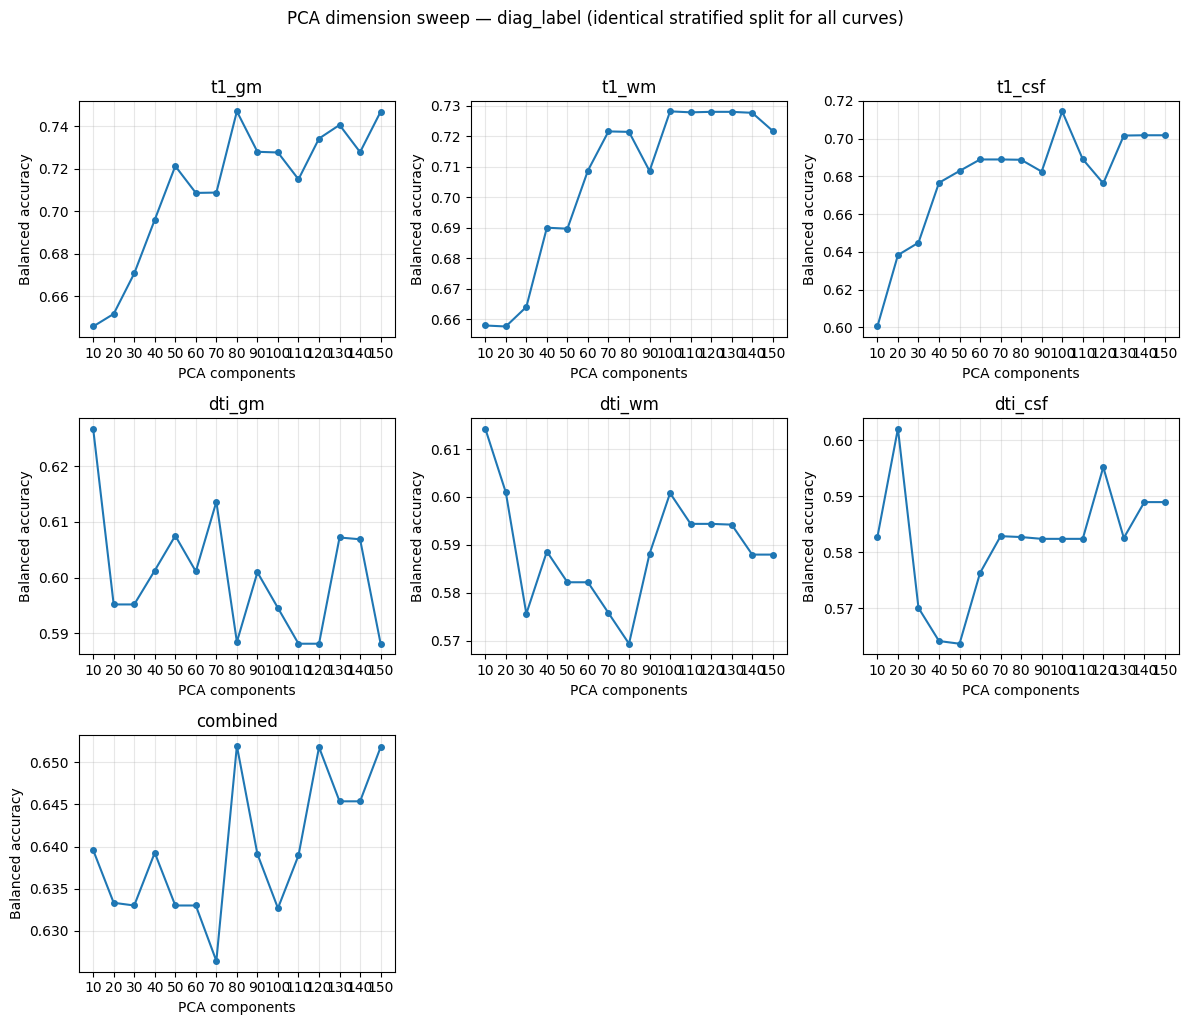

In [12]:
# 7 subplots: PCA components vs balanced accuracy
plot_order = list(MODALITY_ORDER) + ["combined"]
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.ravel()
for i, name in enumerate(plot_order):
    ax = axes[i]
    sub = pca_sweep_results.loc[pca_sweep_results["dataset"] == name]
    ax.plot(
        sub["n_components"],
        sub["bAcc"],
        marker="o",
        ms=4,
        color="C0",
    )
    ax.set_title(name)
    ax.set_xlabel("PCA components")
    ax.set_ylabel("Balanced accuracy")
    ax.set_xticks(N_COMPONENTS_RANGE)
    ax.grid(True, alpha=0.3)
for j in range(len(plot_order), len(axes)):
    axes[j].set_visible(False)
fig.suptitle(
    f"PCA dimension sweep — {LABEL_COL} (identical stratified split for all curves)",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [13]:
# --- CN vs Dementia only (exclude MCI): seven SVMs with chosen PCA sizes ----------
# PC counts: t1_gm 80, t1_wm 120, t1_csf 100, dti_gm 70, dti_wm 100, dti_csf 120, combined 130.
# (You also had a separate "combined: 150" line; using 130 as the closing value—set to 150 if desired.)
TEST_SIZE, SPLIT_SEED, SVM_SEED = 0.2, 0, 0
MOD_ORDER = ("t1_gm", "t1_wm", "t1_csf", "dti_gm", "dti_wm", "dti_csf")
N_PC_BY_DATASET = {
    "t1_gm": 80,
    "t1_wm": 120,
    "t1_csf": 100,
    "dti_gm": 70,
    "dti_wm": 100,
    "dti_csf": 120,
    "combined": 130,
}

In [14]:
mask_cd = meta["group"].isin(["CN", "Dementia"]).values
y = (meta.loc[mask_cd, "group"] == "Dementia").astype(int).values
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=TEST_SIZE, stratify=y, random_state=SPLIT_SEED
)
y_tr, y_te = y[idx_train], y[idx_test]

rows_cn_dem = []
for name in list(MOD_ORDER) + ["combined"]:
    n_pc = N_PC_BY_DATASET[name]
    if name != "combined":
        X = X_raw[name][mask_cd].astype(np.float32)
        scaler = StandardScaler().fit(X[idx_train])
        Xs = scaler.transform(X).astype(np.float32)
        X_tr, X_te = Xs[idx_train], Xs[idx_test]
    else:
        X_cf = np.hstack([X_raw[m] for m in MOD_ORDER]).astype(np.float32)
        mm = MinMaxScaler(feature_range=(0, 1)).fit(X_cf[meta["group"].eq("CN").values])
        X_01 = mm.transform(X_cf).astype(np.float32)
        Xv = X_01[mask_cd]
        X_tr, X_te = Xv[idx_train], Xv[idx_test]

    pca = PCA(n_components=n_pc, random_state=SPLIT_SEED).fit(X_tr)
    Z_tr = pca.transform(X_tr)
    Z_te = pca.transform(X_te)
    clf = SVC(class_weight="balanced", random_state=SVM_SEED).fit(Z_tr, y_tr)
    y_pred = clf.predict(Z_te)
    bacc = balanced_accuracy_score(y_te, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    rows_cn_dem.append(
        {"dataset": name, "n_pc": n_pc, "bAcc": bacc, "Sens": sens, "Spec": spec}
    )
    print(
        f"{name:>9s}  n_pc={n_pc:3d}  bAcc={bacc:.4f}  Sens={sens:.4f}  Spec={spec:.4f}"
    )

cn_vs_dem_results = pd.DataFrame(rows_cn_dem)
print(
    f"\nCN vs Dementia  n={len(y)}  CN={(y == 0).sum()}  Dementia={(y == 1).sum()}  "
    f"train={len(idx_train)}  test={len(idx_test)}  (scaler/PCA fit on train only)"
)
cn_vs_dem_results

    t1_gm  n_pc= 80  bAcc=0.8009  Sens=0.7500  Spec=0.8519
    t1_wm  n_pc=120  bAcc=0.8243  Sens=0.8214  Spec=0.8272
   t1_csf  n_pc=100  bAcc=0.7948  Sens=0.7500  Spec=0.8395
   dti_gm  n_pc= 70  bAcc=0.6739  Sens=0.6071  Spec=0.7407
   dti_wm  n_pc=100  bAcc=0.6623  Sens=0.5714  Spec=0.7531
  dti_csf  n_pc=120  bAcc=0.6389  Sens=0.5000  Spec=0.7778
 combined  n_pc=130  bAcc=0.8003  Sens=0.7857  Spec=0.8148

CN vs Dementia  n=541  CN=400  Dementia=141  train=432  test=109  (scaler/PCA fit on train only)


,dataset,n_pc,bAcc,Sens,Spec
0,t1_gm,80,0.800926,0.750000,0.851852
1,t1_wm,120,0.824295,0.821429,0.827160
2,t1_csf,100,0.794753,0.750000,0.839506
3,dti_gm,70,0.673942,0.607143,0.740741
4,dti_wm,100,0.662257,0.571429,0.753086
5,dti_csf,120,0.638889,0.500000,0.777778
6,combined,130,0.800265,0.785714,0.814815


In [27]:
# CN vs Dementia — short cohort vs long (`cn_vs_dem_results` cell above)
def _cn_vs_dem_eval_short(meta_df, X_raw_dict, cohort_tag):
    """Same protocol as the previous cell's CN vs Dementia loop (StandardScaler / MinMax -> PCA -> SVC)."""
    mask_cd = meta_df["group"].isin(["CN", "Dementia"]).values
    y = (meta_df.loc[mask_cd, "group"] == "Dementia").astype(int).values
    if y.sum() == 0 or y.sum() == len(y):
        print(f"[{cohort_tag}] skip: CN/Dementia subset has a single class (n={len(y)}).")
        return pd.DataFrame(columns=["dataset", "n_pc", "bAcc", "Sens", "Spec"])
    idx = np.arange(len(y))
    try:
        idx_train, idx_test = train_test_split(
            idx, test_size=TEST_SIZE, stratify=y, random_state=SPLIT_SEED
        )
    except ValueError as exc:
        print(f"[{cohort_tag}] stratified train_test_split failed: {exc}")
        return pd.DataFrame(columns=["dataset", "n_pc", "bAcc", "Sens", "Spec"])
    y_tr, y_te = y[idx_train], y[idx_test]

    rows_cn_dem = []
    for name in list(MOD_ORDER) + ["combined"]:
        n_pc_requested = N_PC_BY_DATASET[name]
        if name != "combined":
            X = X_raw_dict[name][mask_cd].astype(np.float32)
            scaler = StandardScaler().fit(X[idx_train])
            Xs = scaler.transform(X).astype(np.float32)
            X_tr, X_te = Xs[idx_train], Xs[idx_test]
        else:
            X_cf = np.hstack([X_raw_dict[m] for m in MOD_ORDER]).astype(np.float32)
            mm = MinMaxScaler(feature_range=(0, 1)).fit(
                X_cf[meta_df["group"].eq("CN").values]
            )
            X_01 = mm.transform(X_cf).astype(np.float32)
            Xv = X_01[mask_cd]
            X_tr, X_te = Xv[idx_train], Xv[idx_test]

        n_eff = min(
            int(n_pc_requested),
            X_tr.shape[0],
            max(1, X_tr.shape[1]),
        )
        if n_eff != n_pc_requested:
            print(
                f"[{cohort_tag}] {name}: n_pc {n_pc_requested} -> {n_eff} "
                f"(cap by n_train={X_tr.shape[0]}, n_features={X_tr.shape[1]})"
            )

        try:
            pca = PCA(n_components=n_eff, random_state=SPLIT_SEED).fit(X_tr)
        except Exception as exc:
            print(f"[{cohort_tag}] {name}: PCA fit failed ({exc}); skipping row.")
            continue
        Z_tr = pca.transform(X_tr)
        Z_te = pca.transform(X_te)
        clf = SVC(class_weight="balanced", random_state=SVM_SEED).fit(Z_tr, y_tr)
        y_pred = clf.predict(Z_te)
        bacc = balanced_accuracy_score(y_te, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else float("nan")
        spec = tn / (tn + fp) if (tn + fp) else float("nan")
        rows_cn_dem.append(
            {"dataset": name, "n_pc": n_eff, "bAcc": bacc, "Sens": sens, "Spec": spec}
        )
        print(
            f"[{cohort_tag}] {name:>9s}  n_pc={n_eff:3d}  bAcc={bacc:.4f}  Sens={sens:.4f}  Spec={spec:.4f}"
        )

    print(
        f"[{cohort_tag}] CN vs Dementia  n={len(y)}  CN={(y == 0).sum()}  Dementia={(y == 1).sum()}  "
        f"train={len(idx_train)}  test={len(idx_test)}  (fit on train only)"
    )
    return pd.DataFrame(rows_cn_dem)

In [ ]:
cn_vs_dem_short_only = _cn_vs_dem_eval_short(meta_short, X_raw_short, "short")

cols_compare = ["cohort", "dataset", "n_pc", "bAcc", "Sens", "Spec"]
parts = [cn_vs_dem_results.assign(cohort="long")]
if not cn_vs_dem_short_only.empty:
    parts.append(cn_vs_dem_short_only.assign(cohort="short"))
cn_vs_dem_compare = (
    pd.concat(parts, ignore_index=True)[cols_compare].sort_values(["dataset", "cohort"])
)
cn_vs_dem_compare

[short]     t1_gm  n_pc= 80  bAcc=0.7561  Sens=0.5455  Spec=0.9667
[short]     t1_wm  n_pc=120  bAcc=0.8470  Sens=0.7273  Spec=0.9667
[short]    t1_csf  n_pc=100  bAcc=0.7848  Sens=0.6364  Spec=0.9333
